# Liquid State Machine (LSM) for stock time series (simplified)
This notebook implements a simplified spiking reservoir (rate-to-spike conversion),
trains a linear readout on spike counts, evaluates performance, and saves the model.

Import libraries

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score
from data_utils import load_close_matrix, train_val_test_split, windowed_dataset, select_random_ticker
from logger import get_logger

MODELS_DIR = os.path.join(os.getcwd(), "models")
os.makedirs(MODELS_DIR, exist_ok=True)

# Initialize logger
logger = get_logger("lsm_reservoir")

1) Load data (first ticker)

In [10]:
# Load all ticker data
df = load_close_matrix()
if df.empty:
    logger.error("No ticker CSVs found in ./tickers. Run ticker.py first.")
    raise RuntimeError("No ticker CSVs found in ./tickers. Run ticker.py first.")

# Select a random ticker (reproducible with seed=42)
series = select_random_ticker(df, random_state=3)
logger.info(f"Using randomly selected ticker: {series.name}, length: {len(series)}")
print(f"Using randomly selected ticker: {series.name}, length: {len(series)}")

2026-03-08 00:37:42,475 - data_utils - INFO - Found 10 ticker CSV files
2026-03-08 00:37:42,481 - data_utils - INFO - Loading data from 10 files...
2026-03-08 00:37:42,625 - data_utils - INFO - Created merged matrix with shape (255, 10)
2026-03-08 00:37:42,627 - data_utils - INFO - Available tickers: ['ARLO', 'BBWI', 'DDL', 'DFH', 'KD', 'KMT', 'PPL', 'PSFE', 'SEM', 'SMR']
2026-03-08 00:37:42,629 - data_utils - INFO - Randomly selected ticker: SEM, length: 255
2026-03-08 00:37:42,631 - lsm_reservoir - INFO - Using randomly selected ticker: SEM, length: 255


Using randomly selected ticker: SEM, length: 255


2) Simple LSM (rate->spike conversion + leaky integrate-and-fire style reservoir)

In [11]:
class SimpleLSM:
    def __init__(self, n_neurons=500, connectivity=0.1, tau=10.0, dt=1.0, random_state=42):
        self.logger = get_logger("lsm")
        self.n_neurons = n_neurons
        self.connectivity = connectivity
        self.tau = tau
        self.dt = dt
        self.rs = np.random.Generator(np.random.PCG64(random_state))
        self.W = None
        self.win = None
        self.logger.debug(f"Initialized LSM with n_neurons={n_neurons}, connectivity={connectivity}, tau={tau}, dt={dt}")

    def _init(self, n_inputs):
        self.logger.debug(f"Initializing LSM weights for {n_inputs} inputs")
        self.win = (self.rs.random((self.n_neurons, n_inputs)) - 0.5) * 2.0
        W = (self.rs.random((self.n_neurons, self.n_neurons)) - 0.5)
        mask = self.rs.random(W.shape) < self.connectivity
        W *= mask
        # scale to moderate activity
        W *= 0.5
        self.W = W
        self.logger.debug(f"LSM weights initialized - win shape: {self.win.shape}, W shape: {self.W.shape}")

    def run_spiking(self, inputs, threshold=0.5):
        # inputs: (T, n_inputs)
        T, n_inputs = inputs.shape
        self.logger.debug(f"Running LSM spiking for {T} timesteps with {n_inputs} inputs")
        if self.W is None:
            self._init(n_inputs)
        v = np.zeros(self.n_neurons)
        spikes = np.zeros((T, self.n_neurons))
        for t in range(T):
            u = inputs[t]
            I = self.win.dot(u) + self.W.dot(spikes[t-1] if t>0 else np.zeros(self.n_neurons))
            # leaky integrate
            v = v + ( -v + I ) * (self.dt / self.tau)
            s = (v > threshold).astype(float)
            # reset membrane potential where spikes occurred
            v[s==1] = 0.0
            spikes[t] = s
        self.logger.debug(f"LSM spiking completed, spikes shape: {spikes.shape}")
        return spikes

3) Prepare windows and normalize

In [12]:
train, val, test = train_val_test_split(series, train_frac=0.7, val_frac=0.15)
window_size = 10
logger.info(f"Data split - Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")
logger.info(f"Using window size: {window_size}")
X_train, y_train = windowed_dataset(train, window_size)
X_val, y_val = windowed_dataset(np.concatenate([train[-window_size:], val]), window_size)
X_test, y_test = windowed_dataset(np.concatenate([val[-window_size:], test]), window_size)

mu = X_train.mean()
sigma = X_train.std() + 1e-9
X_train_n = (X_train - mu) / sigma
X_val_n = (X_val - mu) / sigma
X_test_n = (X_test - mu) / sigma
logger.debug(f"Data normalized - mu: {mu:.6f}, sigma: {sigma:.6f}")

2026-03-08 00:37:42,673 - lsm_reservoir - INFO - Data split - Train: 178, Val: 38, Test: 39
2026-03-08 00:37:42,675 - lsm_reservoir - INFO - Using window size: 10


4) Run LSM and train readout

In [13]:
lsm = SimpleLSM(n_neurons=400, connectivity=0.05, tau=8.0)
logger.info(f"Created LSM with {lsm.n_neurons} neurons")
def windows_to_inputs(X):
    return X.reshape(X.shape[0], X.shape[1], 1)

def spike_features(lsm, x_n):
    feats = []
    for w in x_n:
        seq = w.reshape(len(w), 1)
        spikes = lsm.run_spiking(seq, threshold=0.4)
        # feature: spike counts per neuron over the window
        feats.append(spikes.sum(axis=0))
    return np.vstack(feats)

R_train = spike_features(lsm, X_train_n)
R_val = spike_features(lsm, X_val_n)
R_test = spike_features(lsm, X_test_n)

ridge = Ridge(alpha=1.0, random_state=42)
logger.info("Training ridge regression readout...")
ridge.fit(R_train, y_train)
y_pred = ridge.predict(R_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# 1) Baseline Comparison - Naive Last-Value
naive_pred = y_test[:-1]
naive_mse = mean_squared_error(y_test[1:], naive_pred)
naive_mae = mean_absolute_error(y_test[1:], naive_pred)
improvement_mse = ((naive_mse - mse) / naive_mse) * 100
improvement_mae = ((naive_mae - mae) / naive_mae) * 100

# 2) Directional Accuracy
y_true_direction = (y_test[1:] > y_test[:-1]).astype(int)
y_pred_direction = (y_pred[1:] > y_pred[:-1]).astype(int)
directional_acc = accuracy_score(y_true_direction, y_pred_direction) * 100

# Log all metrics
logger.info(f"LSM Test MSE: {mse:.6f}, MAE: {mae:.6f}")
logger.info(f"R-squared: {r2:.4f}")
logger.info(f"Naive Baseline MSE: {naive_mse:.6f}, MAE: {naive_mae:.6f}")
logger.info(f"LSM vs Naive Improvement: MSE {improvement_mse:.2f}%, MAE {improvement_mae:.2f}%")
logger.info(f"Directional Accuracy: {directional_acc:.2f}%")

print(f"LSM Test MSE: {mse:.6f}, MAE: {mae:.6f}")
print(f"R-squared: {r2:.4f}")
print(f"Naive Baseline MSE: {naive_mse:.6f}, MAE: {naive_mae:.6f}")
print(f"LSM vs Naive Improvement: MSE {improvement_mse:.2f}%, MAE {improvement_mae:.2f}%")
print(f"Directional Accuracy: {directional_acc:.2f}%")

2026-03-08 00:37:42,705 - lsm_reservoir - INFO - Created LSM with 400 neurons
2026-03-08 00:37:42,937 - lsm_reservoir - INFO - Training ridge regression readout...
2026-03-08 00:37:42,972 - lsm_reservoir - INFO - LSM Test MSE: 0.953110, MAE: 0.864457
2026-03-08 00:37:42,974 - lsm_reservoir - INFO - R-squared: -2.1797
2026-03-08 00:37:42,975 - lsm_reservoir - INFO - Naive Baseline MSE: 0.094530, MAE: 0.175017
2026-03-08 00:37:42,978 - lsm_reservoir - INFO - LSM vs Naive Improvement: MSE -908.26%, MAE -393.93%
2026-03-08 00:37:42,981 - lsm_reservoir - INFO - Directional Accuracy: 44.74%


LSM Test MSE: 0.953110, MAE: 0.864457
R-squared: -2.1797
Naive Baseline MSE: 0.094530, MAE: 0.175017
LSM vs Naive Improvement: MSE -908.26%, MAE -393.93%
Directional Accuracy: 44.74%


5) Visualize predictions

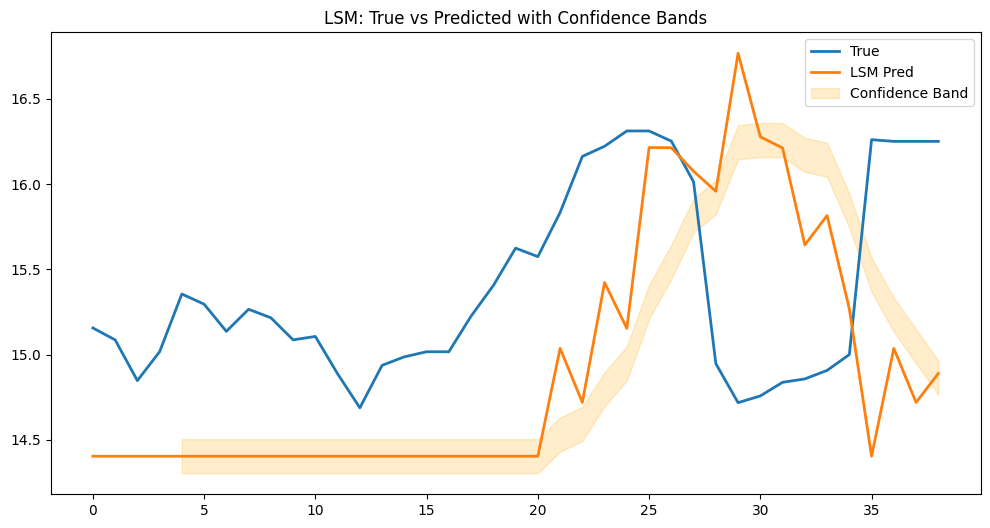

In [14]:
plt.figure(figsize=(12,6))
plt.plot(y_test, label="True", linewidth=2)
plt.plot(y_pred, label="LSM Pred", linewidth=2)
# Add 5-day moving average as confidence band
pred_series = pd.Series(y_pred)
ma_band = pred_series.rolling(5).mean()
plt.fill_between(range(len(y_pred)), ma_band - 0.1, ma_band + 0.1, alpha=0.2, color='orange', label='Confidence Band')
plt.legend()
plt.title("LSM: True vs Predicted with Confidence Bands")
plt.show()

6) Residual Analysis

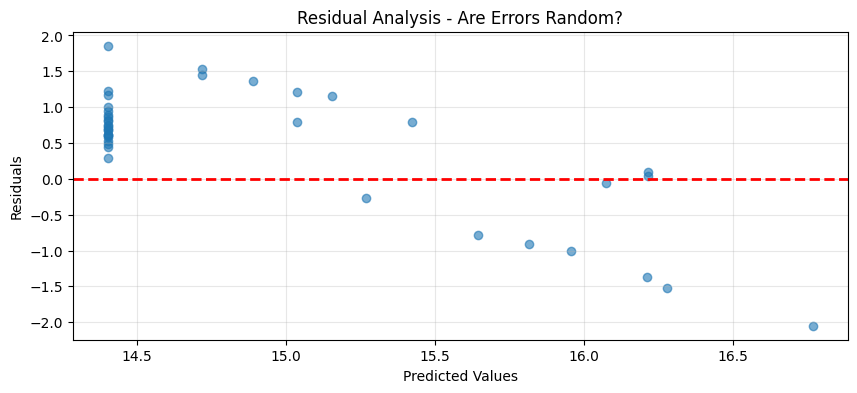

2026-03-08 00:37:43,460 - lsm_reservoir - INFO - Residual Mean: 0.455425
2026-03-08 00:37:43,464 - lsm_reservoir - INFO - Residual Std: 0.863538


Residual Mean: 0.455425
Residual Std: 0.863538


In [15]:
residuals = y_test - y_pred
plt.figure(figsize=(10,4))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Analysis - Are Errors Random?')
plt.grid(True, alpha=0.3)
plt.show()

# Additional residual statistics
logger.info(f"Residual Mean: {np.mean(residuals):.6f}")
logger.info(f"Residual Std: {np.std(residuals):.6f}")
print(f"Residual Mean: {np.mean(residuals):.6f}")
print(f"Residual Std: {np.std(residuals):.6f}")

7) Save model

In [16]:
joblib.dump({"lsm": lsm, "readout": ridge, "mu": mu, "sigma": sigma, "window_size": window_size}, os.path.join(MODELS_DIR, "lsm_model.pkl"))
logger.info("Saved LSM model to models/lsm_model.pkl")
print("[OK] Saved LSM model to models/lsm_model.pkl")

2026-03-08 00:37:43,495 - lsm_reservoir - INFO - Saved LSM model to models/lsm_model.pkl


[OK] Saved LSM model to models/lsm_model.pkl
